# MHD Simulation Test

### This first case is for a sub-Aflvenic field ~0.7 taken from Cho-ENO folder of simulations
- ./256/b1p1/t750/
- D = 256, Ms = 0.7, MA = 0.7 -- Sub-Alfvenic


In [1]:
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

## load MHD files

In [2]:
def load_mhd_fits(folder_path):
    """
    Reads MHD FITS files from folder and returns dictionary of 3D arrays.
    Expected keywords in filenames:
        density: 'dens' or 'rho'
        magnetic field: 'Bx', 'By', 'Bz'
        velocity: 'Vx', 'Vy', 'Vz'
    """

    data_dict = {
        'density': None,
        'Bx': None,
        'By': None,
        'Bz': None,
        'Vx': None,
        'Vy': None,
        'Vz': None
    }

    for filename in os.listdir(folder_path):
        if filename.endswith('.fits'):
            filepath = os.path.join(folder_path, filename)

            with fits.open(filepath) as hdul:
                data = hdul[0].data
                print(hdul[0].header)

            # Ensure correct shape
            if data.shape != (256, 256, 256):
                raise ValueError(f"{filename} has incorrect shape {data.shape}")

            fname = filename.lower()

            if 'dens' in fname or 'rho' in fname:
                data_dict['density'] = np.array(data)

            elif 'magx' in fname:
                data_dict['Bx'] = np.array(data)

            elif 'magy' in fname:
                data_dict['By'] = np.array(data)

            elif 'magz' in fname:
                data_dict['Bz'] = np.array(data)

            elif 'velx' in fname:
                data_dict['Vx'] = np.array(data)

            elif 'vely' in fname:
                data_dict['Vy'] = np.array(data)

            elif 'velz' in fname:
                data_dict['Vz'] = np.array(data)

    # Check that all fields were loaded
    for key, value in data_dict.items():
        if value is None:
            raise ValueError(f"Missing file for {key}")

    return data_dict

In [42]:
folder = "./MHD_Data/sub_alfvenic/"
mhd_data = load_mhd_fits(folder)

rho = mhd_data['density']
Bx  = mhd_data['Bx']
By  = mhd_data['By']
Bz  = mhd_data['Bz']
Vx  = mhd_data['Vx']
Vy  = mhd_data['Vy']
Vz  = mhd_data['Vz']

print(rho.shape)  # should be (256,256,256)

SIMPLE  =                    T / Written by IDL:  Wed Nov  8 11:49:11 2017      BITPIX  =                  -32 / Number of bits per data pixel                  NAXIS   =                    3 / Number of data axes                            NAXIS1  =                  256 /                                                NAXIS2  =                  256 /                                                NAXIS3  =                  256 /                                                EXTEND  =                    T / FITS data may contain extensions               DATE    = '2017-11-08'         / Creation UTC (CCCC-MM-DD) date of FITS header  COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    END                                                                                                                                                                                                     

## Visual check with Fits image

(0.0, 256.0)

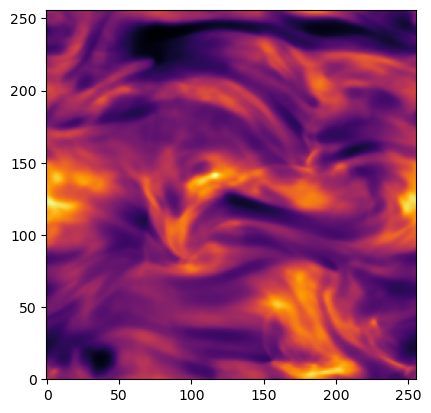

In [43]:
# rho[X,:,:] -- each layer along LOS

plt.imshow(rho[1,:,:], cmap='inferno')
plt.ylim([0, 256])

In [44]:
# =========================
# STOKES FROM FIELD
# =========================
Bperp2 = Bx**2 + By**2
Btot2 = Bperp2 + Bz**2 + 1e-12

cos2g = Bperp2 / Btot2
q = (By**2 - Bx**2) / Btot2
u = (2 * Bx * By) / Btot2

# =========================
# LOS INTEGRATION
# =========================
Q = q.sum(axis=0)
U = u.sum(axis=0)
# I_obs = I0 * g_size

P_obs = np.sqrt(Q**2 + U**2) / np.shape(rho[0][0])  # Normalize by number of layers along LOS
phi_obs = 0.5 * np.arctan2(U, Q)
cos2g_LOS = cos2g.mean(axis=0)

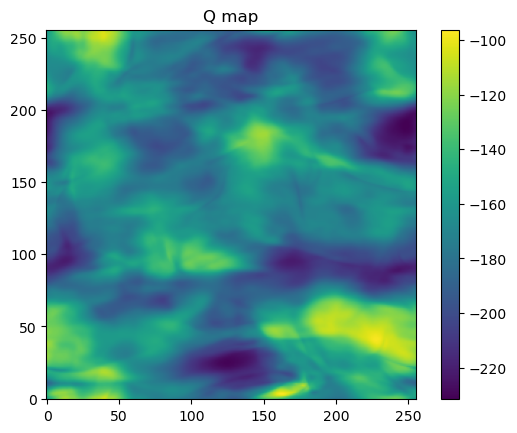

In [45]:
plt.figure()
plt.imshow(Q, origin='lower')
plt.colorbar()
plt.title("Q map")
plt.show()

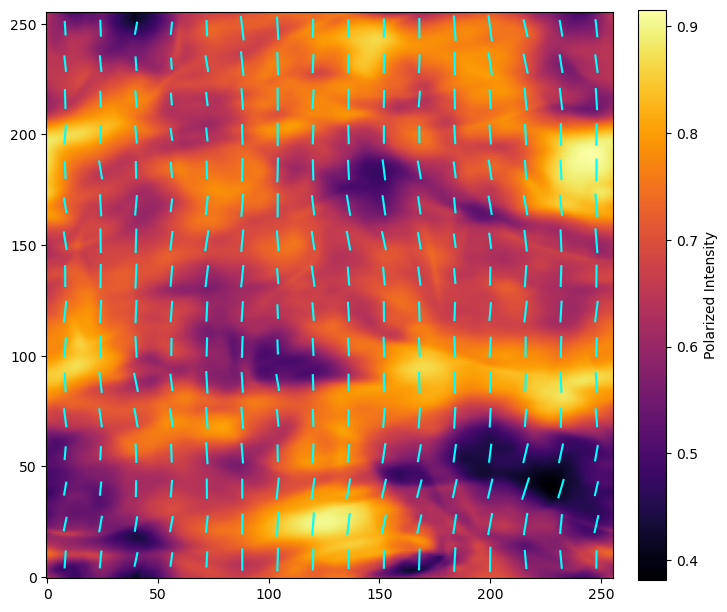

In [46]:
nskip = 16

fig, ax = plt.subplots(figsize=(8,8))

ny, nx = Q.shape

phi = 0.5 * np.arctan2(U, Q)
x = np.cos(phi)*P_obs
y = np.sin(phi)*P_obs

im = ax.imshow(P_obs, cmap='inferno', origin='lower')

X, Y = np.meshgrid(
    np.arange(nx) + nskip//2,
    np.arange(ny) + nskip//2,
    indexing='ij'
)

ax.quiver(
    X[::nskip, ::nskip],
    Y[::nskip, ::nskip],
    x[::nskip, ::nskip],
    y[::nskip, ::nskip],
    pivot='middle',
    headlength=0,
    headaxislength=0,
    color='cyan'
)

ax.set_aspect('equal')

plt.colorbar(im, label='Polarized Intensity',fraction=0.046, pad=0.04)
plt.show()

/var/folders/q3/hykz569d1r1c51lc9dq_8cb00000gn/T/ipykernel_27623/2697211944.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9)


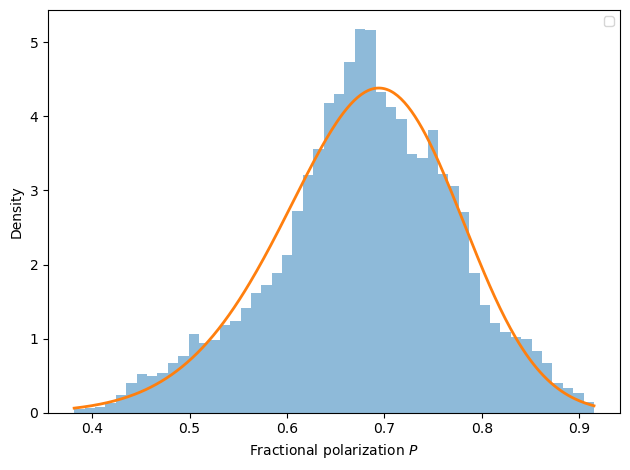

In [47]:
from scipy.stats import skew, skewnorm

Pflat = P_obs.flatten()

skew_val = skew(Pflat, bias=False)
a, loc, scale = skewnorm.fit(Pflat)
x = np.linspace(Pflat.min(), Pflat.max(), 300)
pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

plt.hist(Pflat, bins=50, alpha=0.5, density=True)
plt.plot(x, pdf_skew, lw=2)

plt.xlabel("Fractional polarization $P$")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [61]:
from geometries_kolmo import uniform_field_kolmo

P, PHI, COS = uniform_field_kolmo(M_A = 0.70, Bz_true=0, angle_range=[np.pi/4,np.pi/4], g_size=256, plotting=False)

MHD pol skewness:  -0.2903673815459088
Kolmo pol skewness:  -0.5071588276262079


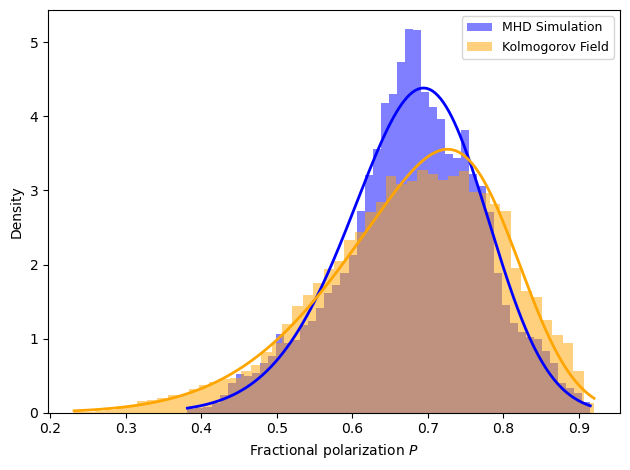

In [62]:
Pflat_MHD = P_obs.flatten()
Pflat_kolmo = P.flatten()

skew_val_MHD = skew(Pflat_MHD, bias=False)
skew_val_kolmo = skew(Pflat_kolmo, bias=False)

a_MHD, loc_MHD, scale_MHD = skewnorm.fit(Pflat_MHD)
a_kolmo, loc_kolmo, scale_kolmo = skewnorm.fit(Pflat_kolmo)

x_MHD = np.linspace(Pflat_MHD.min(), Pflat_MHD.max(), 300)
x_kolmo = np.linspace(Pflat_kolmo.min(), Pflat_kolmo.max(), 300)

pdf_skew_MHD = skewnorm.pdf(x_MHD, a_MHD, loc=loc_MHD, scale=scale_MHD)
pdf_skew_kolmo = skewnorm.pdf(x_kolmo, a_kolmo, loc=loc_kolmo, scale=scale_kolmo)

print('MHD pol skewness: ', skew(Pflat_MHD, bias=False))
print('Kolmo pol skewness: ',skew(Pflat_kolmo, bias=False))

plt.hist(Pflat_MHD, bins=50, alpha=0.5, density=True, color='blue', label='MHD Simulation')
plt.hist(Pflat_kolmo, bins=50, alpha=0.5, density=True, color='orange', label='Kolmogorov Field')

plt.plot(x_MHD, pdf_skew_MHD, lw=2, color='blue')
plt.plot(x_kolmo, pdf_skew_kolmo, lw=2, color='orange')

plt.xlabel("Fractional polarization $P$")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
print()

# Super-Alfvenic Simulation

In [63]:
folder = "./MHD_Data/super_alfvenic/"
mhd_data = load_mhd_fits(folder)

rho = mhd_data['density']
Bx  = mhd_data['Bx']
By  = mhd_data['By']
Bz  = mhd_data['Bz']
Vx  = mhd_data['Vx']
Vy  = mhd_data['Vy']
Vz  = mhd_data['Vz']

print(rho.shape)  # should be (256,256,256)

SIMPLE  =                    T / Written by IDL:  Tue Nov  7 19:12:40 2017      BITPIX  =                  -32 / Number of bits per data pixel                  NAXIS   =                    3 / Number of data axes                            NAXIS1  =                  256 /                                                NAXIS2  =                  256 /                                                NAXIS3  =                  256 /                                                EXTEND  =                    T / FITS data may contain extensions               DATE    = '2017-11-08'         / Creation UTC (CCCC-MM-DD) date of FITS header  COMMENT FITS (Flexible Image Transport System) format is defined in 'Astronomy  COMMENT and Astrophysics', volume 376, page 359; bibcode 2001A&A...376..359H    END                                                                                                                                                                                                     

(0.0, 256.0)

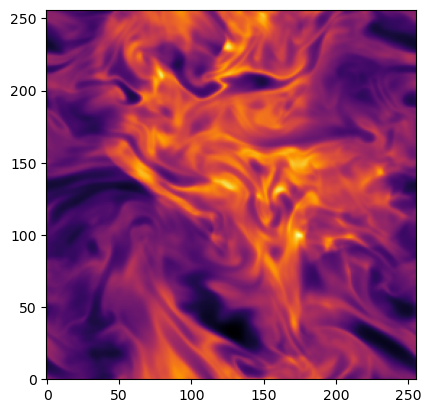

In [64]:
# rho[X,:,:] -- each layer along LOS

plt.imshow(rho[1,:,:], cmap='inferno')
plt.ylim([0, 256])

In [65]:
# =========================
# STOKES FROM FIELD
# =========================
Bperp2 = Bx**2 + By**2
Btot2 = Bperp2 + Bz**2 + 1e-12

cos2g = Bperp2 / Btot2
q = (By**2 - Bx**2) / Btot2
u = (2 * Bx * By) / Btot2

# =========================
# LOS INTEGRATION
# =========================
Q = q.sum(axis=0)
U = u.sum(axis=0)
# I_obs = I0 * g_size

P_obs = np.sqrt(Q**2 + U**2) / np.shape(rho[0][0])  # Normalize by number of layers along LOS
phi_obs = 0.5 * np.arctan2(U, Q)
cos2g_LOS = cos2g.mean(axis=0)

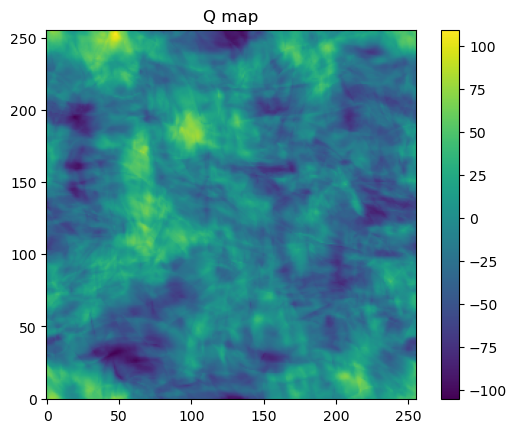

In [66]:
plt.figure()
plt.imshow(Q, origin='lower')
plt.colorbar()
plt.title("Q map")
plt.show()

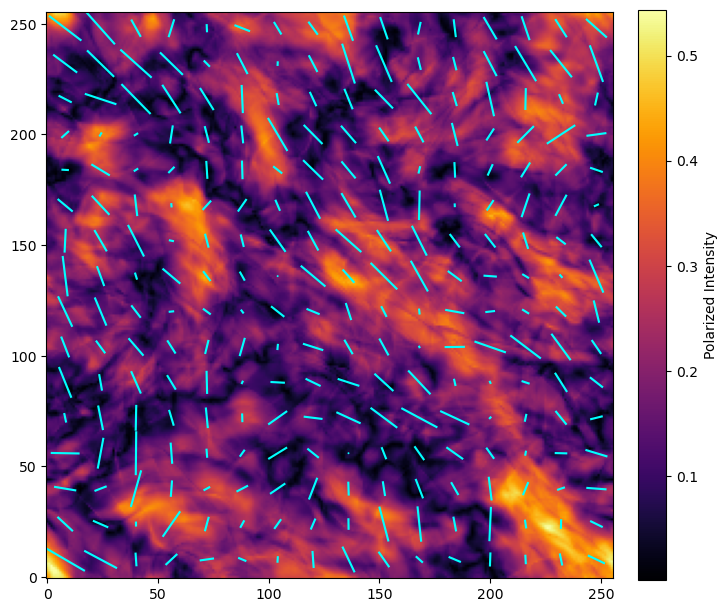

In [67]:
nskip = 16

fig, ax = plt.subplots(figsize=(8,8))

ny, nx = Q.shape

phi = 0.5 * np.arctan2(U, Q)
x = np.cos(phi)*P_obs
y = np.sin(phi)*P_obs

im = ax.imshow(P_obs, cmap='inferno', origin='lower')

X, Y = np.meshgrid(
    np.arange(nx) + nskip//2,
    np.arange(ny) + nskip//2,
    indexing='ij'
)

ax.quiver(
    X[::nskip, ::nskip],
    Y[::nskip, ::nskip],
    x[::nskip, ::nskip],
    y[::nskip, ::nskip],
    pivot='middle',
    headlength=0,
    headaxislength=0,
    color='cyan'
)

ax.set_aspect('equal')

plt.colorbar(im, label='Polarized Intensity',fraction=0.046, pad=0.04)
plt.show()

/var/folders/q3/hykz569d1r1c51lc9dq_8cb00000gn/T/ipykernel_27623/2697211944.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9)


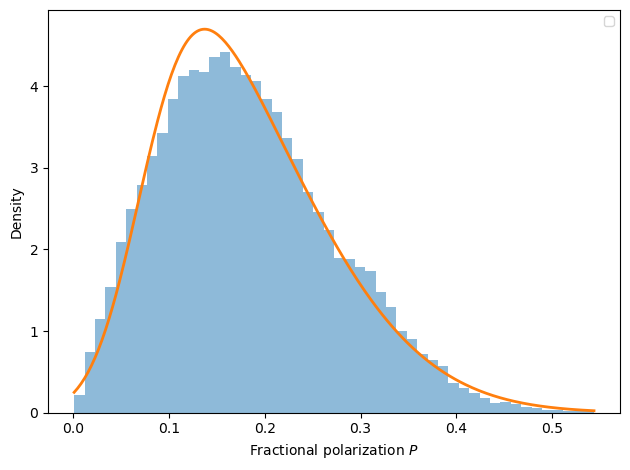

In [68]:
from scipy.stats import skew, skewnorm

Pflat = P_obs.flatten()

skew_val = skew(Pflat, bias=False)
a, loc, scale = skewnorm.fit(Pflat)
x = np.linspace(Pflat.min(), Pflat.max(), 300)
pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

plt.hist(Pflat, bins=50, alpha=0.5, density=True)
plt.plot(x, pdf_skew, lw=2)

plt.xlabel("Fractional polarization $P$")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [72]:
from geometries_kolmo import uniform_field_kolmo

P, PHI, COS = uniform_field_kolmo(M_A = 2, Bz_true=0, angle_range=[np.pi/4,np.pi/4], g_size=256, plotting=False)

MHD pol skewness:  0.527164215023748
Kolmo pol skewness:  0.1118513391812475


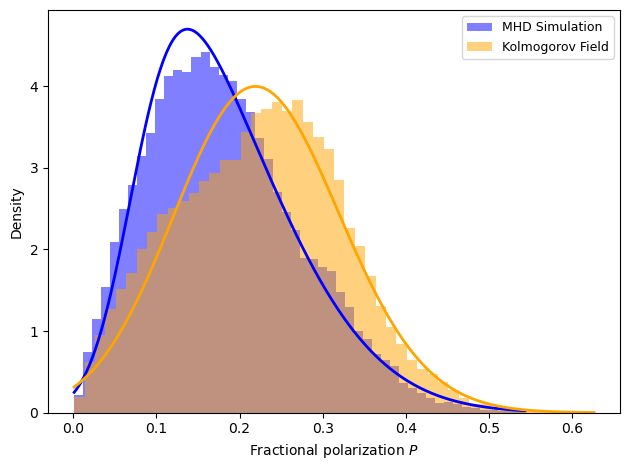

In [73]:
Pflat_MHD = P_obs.flatten()
Pflat_kolmo = P.flatten()

skew_val_MHD = skew(Pflat_MHD, bias=False)
skew_val_kolmo = skew(Pflat_kolmo, bias=False)

a_MHD, loc_MHD, scale_MHD = skewnorm.fit(Pflat_MHD)
a_kolmo, loc_kolmo, scale_kolmo = skewnorm.fit(Pflat_kolmo)

x_MHD = np.linspace(Pflat_MHD.min(), Pflat_MHD.max(), 300)
x_kolmo = np.linspace(Pflat_kolmo.min(), Pflat_kolmo.max(), 300)

pdf_skew_MHD = skewnorm.pdf(x_MHD, a_MHD, loc=loc_MHD, scale=scale_MHD)
pdf_skew_kolmo = skewnorm.pdf(x_kolmo, a_kolmo, loc=loc_kolmo, scale=scale_kolmo)

print('MHD pol skewness: ', skew(Pflat_MHD, bias=False))
print('Kolmo pol skewness: ',skew(Pflat_kolmo, bias=False))

plt.hist(Pflat_MHD, bins=50, alpha=0.5, density=True, color='blue', label='MHD Simulation')
plt.hist(Pflat_kolmo, bins=50, alpha=0.5, density=True, color='orange', label='Kolmogorov Field')

plt.plot(x_MHD, pdf_skew_MHD, lw=2, color='blue')
plt.plot(x_kolmo, pdf_skew_kolmo, lw=2, color='orange')


plt.xlabel("Fractional polarization $P$")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()
